# AI-Based University Major Recommendation System

## Project Overview

This project aims to build an AI-powered recommendation system that predicts the most suitable university major for students based on:

- Academic performance
- Student interests
- Behavioral factors

The system uses a Random Forest Multi-Class Classifier to recommend the Top 3 most suitable majors with confidence scores.


# Workflow

1. Load Dataset  
2. Data Inspection  
3. Data Preprocessing  
4. Feature Encoding  
5. Feature Scaling  
6. Train/Test Split  
7. Model Training  
8. Model Evaluation  
9. Save Model Files  
10. Recommendation Inference  


### Libraries Used

| Library | Purpose |
|---|---|
| pandas | Data handling and preprocessing |
| numpy | Numerical operations |
| matplotlib | Data visualization |
| sklearn | Machine learning and evaluation |
| joblib | Saving and loading models |

##1. Import Libraries

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

##2. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##3. Define Project Paths

In [3]:
BASE_PATH = "/content/drive/MyDrive/Hackathon_Model"

DATA_PATH = os.path.join(BASE_PATH, "Acadimic Dataset.csv")

MODELS_PATH = os.path.join(BASE_PATH, "models")

os.makedirs(MODELS_PATH, exist_ok=True)

##4. Load Dataset

In [4]:
df = pd.read_csv(DATA_PATH)

##5. Dataset Overview

In [5]:
print("=" * 50)
print("Dataset Shape")
print("=" * 50)
print(df.shape)

print("\n")

print("=" * 50)
print("First 5 Rows")
print("=" * 50)
print(df.head())

print("\n")

print("=" * 50)
print("Dataset Info")
print("=" * 50)
print(df.info())

Dataset Shape
(5000, 21)


First 5 Rows
   Math  Biology  Physics  Chemistry  English  Digital_Technology  \
0    64       90       64         69       93                  80   
1    92       82       92         57       83                  89   
2    81       40       51         84       87                  55   
3    95       57       78         58       86                  87   
4    91       90       99         54       76                  86   

   Critical_Thinking  Linguistic_Competencies  Holy_Quran  Ecology  ...  \
0                 92                       70          80       61  ...   
1                 86                       50          50       54  ...   
2                 79                       76          70       64  ...   
3                 97                       88          73       77  ...   
4                 93                       59          82       65  ...   

   Social_Studies  Hadith  Physical_Health  Financial_Literacy  Statistics  \
0              6

##6. Check Missing Values & Duplicates

In [7]:
print("=" * 50)
print("Missing Values")
print("=" * 50)
print(df.isnull().sum())

print("\n")

print("=" * 50)
print("Duplicate Rows")
print("=" * 50)
print(df.duplicated().sum())

Missing Values
Math                       0
Biology                    0
Physics                    0
Chemistry                  0
English                    0
Digital_Technology         0
Critical_Thinking          0
Linguistic_Competencies    0
Holy_Quran                 0
Ecology                    0
Vocational_Education       0
Social_Studies             0
Hadith                     0
Physical_Health            0
Financial_Literacy         0
Statistics                 0
GPA                        0
Grade_Level                0
Attendance_Behavior        0
Interest                   0
Suggested_Major            0
dtype: int64


Duplicate Rows
0


##7. Data Cleaning

In [8]:
df = df.drop_duplicates()

df = df.dropna()

##8. Feature & Target Separation

In [9]:
TARGET_COLUMN = "Suggested_Major"
X = df.drop(columns=[TARGET_COLUMN])

y = df[TARGET_COLUMN]

##9. Encode Categorical Features

In [10]:
feature_encoders = {}

categorical_columns = X.select_dtypes(include=['object']).columns

for column in categorical_columns:

    encoder = LabelEncoder()

    X[column] = encoder.fit_transform(X[column])

    feature_encoders[column] = encoder

##10. Encode Target Labels

In [11]:
target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(y)

##11. Feature Scaling

In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

##12. Train / Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

##13. Build Random Forest Model

In [19]:
model = RandomForestClassifier(
    n_estimators=500,
    max_features='sqrt',
    random_state=42
)

##14. Train Model

In [20]:
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=500, random_state=42)

##15. Make Predictions

In [21]:
y_pred = model.predict(X_test)

##16. Evaluate Model Performance

In [22]:
accuracy = accuracy_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred, average='weighted')

print("=" * 50)
print("Model Evaluation")
print("=" * 50)

print(f"Accuracy Score : {accuracy:.4f}")

print(f"F1 Score       : {f1:.4f}")

print("\n")

print("=" * 50)
print("Classification Report")
print("=" * 50)

print(classification_report(
    y_test,
    y_pred,
    target_names=target_encoder.classes_
))

Model Evaluation
Accuracy Score : 0.6990
F1 Score       : 0.6978


Classification Report
                        precision    recall  f1-score   support

         إدارة الأعمال       0.79      0.72      0.75        36
               الأحياء       0.68      0.59      0.63        46
       الأمن السيبراني       0.58      0.78      0.67        41
               التسويق       0.88      0.74      0.80        38
               التمريض       0.57      0.62      0.59        39
      الذكاء الاصطناعي       0.45      0.54      0.49        35
             الرياضيات       0.74      0.69      0.71        36
               الشريعة       0.95      1.00      0.98        40
          الصحة العامة       0.93      0.93      0.93        40
               الصيدلة       0.36      0.32      0.34        37
         الطب والجراحة       0.36      0.32      0.34        37
              الفيزياء       0.88      0.72      0.79        39
               القانون       0.93      0.93      0.93        40
              

### Evaluation Metrics

| Metric | Purpose |
|---|---|
| Accuracy Score | Overall model performance |
| F1-Score | Balanced evaluation metric |
| Confusion Matrix | Prediction analysis |
| Classification Report | Detailed class performance |

##17. Plot Confusion Matrix

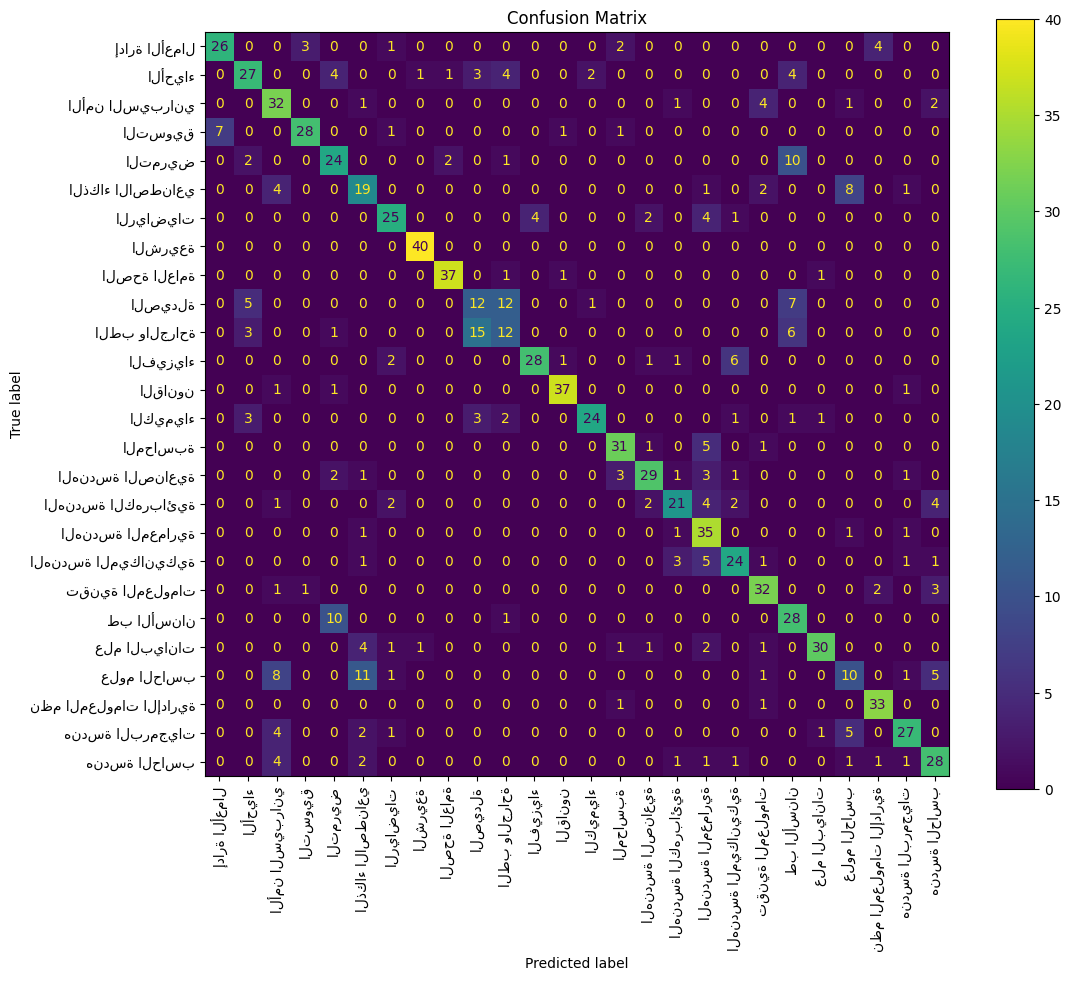

In [23]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(12, 10))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_encoder.classes_
)

display.plot(ax=ax, xticks_rotation=90)

plt.title("Confusion Matrix")

plt.show()

##18. Predict Top 3 Recommended Majors

In [26]:
# Prepare New Student Data

new_student_data = pd.DataFrame({

    'Math': [95],
    'Biology': [55],
    'Physics': [92],
    'Chemistry': [60],
    'English': [88],
    'Digital_Technology': [98],
    'Critical_Thinking': [94],
    'Linguistic_Competencies': [70],
    'Holy_Quran': [80],
    'Ecology': [55],
    'Vocational_Education': [75],
    'Social_Studies': [60],
    'Hadith': [72],
    'Physical_Health': [70],
    'Financial_Literacy': [88],
    'Statistics': [95],
    'GPA': [4.8],
    'Grade_Level': [3],
    'Attendance_Behavior': ['Good'],
    'Interest': ['AI']
})

# Encode Features

for column, encoder in feature_encoders.items():

    new_student_data[column] = encoder.transform(
        new_student_data[column]
    )

# Scale Features

new_student_scaled = scaler.transform(
    new_student_data
)

# Predict Probabilities

prediction_probabilities = model.predict_proba(
    new_student_scaled
)

# Get Top 3 Predictions

top_3_indices = np.argsort(
    prediction_probabilities[0]
)[-3:][::-1]

# Decode Major Names

top_3_majors = target_encoder.inverse_transform(
    top_3_indices
)

# Get Confidence Scores

top_3_scores = prediction_probabilities[0][top_3_indices]

# Display Results

print("=" * 50)
print("Top 3 Recommended Majors")
print("=" * 50)

for i in range(3):

    print(
        f"{i+1}. {top_3_majors[i]} "
        f"({top_3_scores[i] * 100:.2f}%)"
    )

Top 3 Recommended Majors
1. علم البيانات (78.40%)
2. الذكاء الاصطناعي (7.40%)
3. علوم الحاسب (5.80%)


### Recommendation Output

The system predicts:

- Top 3 recommended university majors
- Confidence score for each recommendation

Example Output:

1. Data Science — 78.40%  
2. Artificial Intelligence — 7.40%  
3. Computer Science — 5.80%  


##19. Save Model Files

In [27]:
joblib.dump(model, os.path.join(MODELS_PATH, "major_model.pkl"))

joblib.dump(scaler, os.path.join(MODELS_PATH, "scaler.pkl"))

joblib.dump(target_encoder, os.path.join(MODELS_PATH, "target_encoder.pkl"))

joblib.dump(feature_encoders, os.path.join(MODELS_PATH, "feature_encoders.pkl"))

print("=" * 50)
print("All Files Saved Successfully")
print("=" * 50)

All Files Saved Successfully


### Saved Files

| File | Description |
|---|---|
| major_model.pkl | Trained Random Forest model |
| scaler.pkl | Feature scaling object |
| target_encoder.pkl | Major label encoder |
| feature_encoders.pkl | Encoders for categorical features |


---

# Files Required for Website Integration

The following files should be connected to the backend system:

1. major_model.pkl  
2. scaler.pkl  
3. target_encoder.pkl  
4. feature_encoders.pkl  

The backend system will:

- Receive student input
- Apply preprocessing
- Run prediction
- Return Top 3 recommended majors